 # CS480: Introduction to Quantum Computing

 ## Homework 8: QKD, Oracles & Deutsch-Jozsa

 **Due:** Tuesday 11:59 PM

 **Total Points:** 100 + 15 Bonus



 ### Instructions

 - Complete all exercises in this notebook

 - Run all cells to verify your answers

 - Submit the completed .ipynb file via Gradescope



 ### This homework covers:

 - Part 1: BB84 Key Distribution (25 pts)

 - Part 2: Eavesdropping Detection (15 pts)

 - Part 3: Oracle Construction (20 pts)

 - Part 4: Deutsch-Jozsa Algorithm (25 pts)

 - Part 5: Bernstein-Vazirani (15 pts)

 - Bonus: Mystery Oracle Challenge (15 pts)

In [5]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

simulator = AerSimulator()

def run_circuit(qc, shots=1024):
    """Run a circuit and return measurement counts."""
    job = simulator.run(transpile(qc, simulator), shots=shots)
    return job.result().get_counts()


 ---

 ## Part 1: BB84 Key Distribution (25 points)

 ### Exercise 1.1 (5 points)

 **BB84 Encoding and Measurement**



 Complete the two functions below for encoding and measuring qubits

 in the BB84 protocol.



 | Bit | Z-basis | X-basis |

 |-----|---------|---------|

 | 0   | $\|0\rangle$ | $\|+\rangle$ |

 | 1   | $\|1\rangle$ | $\|-\rangle$ |

In [6]:
def bb84_encode(bit, basis):
    """
    Encode a single bit in the specified basis for BB84.

    Args:
        bit: int, 0 or 1
        basis: str, 'Z' or 'X'

    Returns:
        QuantumCircuit with 1 qubit prepared in the correct state
    """
    qc = QuantumCircuit(1, 1)

    # TODO: If bit == 1, flip the qubit (apply X gate)
    # Your code here

    # TODO: If basis == 'X', rotate into the X-basis (apply H gate)
    # Your code here
    # If bit == 1, flip the qubit (apply X gate)
    if bit == 1:
        qc.x(0)
    
    # If basis == 'X', rotate into X-basis (apply H gate)
    if basis == 'X':
        qc.h(0)
    
    return qc

def bb84_measure(qc, basis):
    """
    Add measurement in the specified basis to a 1-qubit circuit.

    Args:
        qc: QuantumCircuit with 1 qubit, 1 classical bit
        basis: str, 'Z' or 'X'

    Returns:
        Modified QuantumCircuit with measurement added
    """
    # TODO: If basis == 'X', apply H before measuring
    # Your code here

    # TODO: Measure qubit 0 into classical bit 0
    # Your code here
    qc_copy = qc.copy()
    
    # If basis is 'X', rotate back to Z-basis before measuring
    if basis == 'X':
        qc_copy.h(0)
    
    # Measure in the computational (Z) basis
    qc_copy.measure(0, 0)

    return qc_copy 

# Test: matching basis should always give correct bit
print("BB84 Encode/Measure Tests:")
for bit in [0, 1]:
    for basis in ['Z', 'X']:
        qc = bb84_encode(bit, basis)
        qc = bb84_measure(qc, basis)
        counts = run_circuit(qc, shots=100)
        print(f"  bit={bit}, basis={basis}: {counts}")


BB84 Encode/Measure Tests:
  bit=0, basis=Z: {'0': 100}
  bit=0, basis=X: {'0': 100}
  bit=1, basis=Z: {'1': 100}
  bit=1, basis=X: {'1': 100}


 ### Exercise 1.2 (10 points)

 **Full BB84 Protocol**



 Implement a complete BB84 simulation: Alice encodes random bits in

 random bases, Bob measures in random bases, they sift to keep only

 matching-basis bits.

In [7]:
def bb84_protocol(n_bits=100, seed=None):
    """
    Simulate the BB84 protocol (no eavesdropper).

    Args:
        n_bits: number of qubits Alice sends
        seed: random seed for reproducibility

    Returns:
        dict with keys:
            'alice_bits': list of Alice's random bits
            'alice_bases': list of Alice's random bases ('Z' or 'X')
            'bob_bases': list of Bob's random bases
            'bob_results': list of Bob's measurement results
            'matching_indices': list of indices where bases matched
            'shared_key': list of agreed-upon key bits
    """
    if seed is not None:
        np.random.seed(seed)

    # TODO: Alice generates random bits and bases
    alice_bits = [np.random.randint(0, 2) for _ in range(n_bits)]
    alice_bases = [np.random.choice(['Z', 'X']) for _ in range(n_bits)]

    # TODO: Bob generates random bases
    bob_bases = [np.random.choice(['Z', 'X']) for _ in range(n_bits)]

    # TODO: For each qubit, encode with Alice's choice, measure with
    #       Bob's choice, record Bob's result
    bob_results = []
    for i in range(n_bits):
        qc = bb84_encode(alice_bits[i], alice_bases[i])
        qc = bb84_measure(qc, bob_bases[i])
        counts = run_circuit(qc, shots=1)
        measured_bit = int(list(counts.keys())[0])
        bob_results.append(measured_bit)

    # TODO: Sifting — find indices where bases matched
    matching_indices = [i for i in range(n_bits) 
                       if alice_bases[i] == bob_bases[i]]
    

    # TODO: Extract shared key (Alice's bits at matching indices)
    shared_key = [alice_bits[i] for i in matching_indices]

    return {
        'alice_bits': alice_bits,
        'alice_bases': alice_bases,
        'bob_bases': bob_bases,
        'bob_results': bob_results,
        'matching_indices': matching_indices,
        'shared_key': shared_key
    }

# Run and verify
result = bb84_protocol(n_bits=100, seed=42)
print("BB84 Protocol (no eavesdropper):")
print(f"  Qubits sent:    {len(result['alice_bits'])}")
print(f"  Bases matched:  {len(result['matching_indices'])}")
print(f"  Key length:     {len(result['shared_key'])}")

# Verify: zero errors when no eavesdropper
errors = sum(
    result['alice_bits'][i] != result['bob_results'][i]
    for i in result['matching_indices']
)
print(f"  Errors (expect 0): {errors}")


BB84 Protocol (no eavesdropper):
  Qubits sent:    100
  Bases matched:  47
  Key length:     47
  Errors (expect 0): 0


 ### Exercise 1.3 (10 points)

 **BB84 with Eavesdropper**



 Implement Eve's intercept-and-resend attack. Eve measures each qubit

 in a random basis and re-sends based on her result.

In [8]:
def bb84_with_eve(n_bits=100, seed=None):
    """
    Simulate BB84 with an eavesdropper (intercept-and-resend).

    Returns:
        dict with 'error_rate' and all protocol details
    """
    if seed is not None:
        np.random.seed(seed)

    alice_bits = [np.random.randint(0, 2) for _ in range(n_bits)]
    alice_bases = [np.random.choice(['Z', 'X']) for _ in range(n_bits)]
    eve_bases = [np.random.choice(['Z', 'X']) for _ in range(n_bits)]
    bob_bases = [np.random.choice(['Z', 'X']) for _ in range(n_bits)]

    bob_results = []

    for i in range(n_bits):
        # TODO: Step 1 — Alice encodes
        qc_alice = bb84_encode(alice_bits[i], alice_bases[i])

        # TODO: Step 2 — Eve intercepts and measures
        qc_eve = qc_alice.copy()
        qc_eve = bb84_measure(qc_eve, eve_bases[i])
        counts_eve = run_circuit(qc_eve, shots=1)
        eve_bit = int(list(counts_eve.keys())[0])
        
        # TODO: Step 3 — Eve re-sends a new qubit based on her result
        qc_resend = bb84_encode(eve_bit, eve_bases[i])

        # TODO: Step 4 — Bob measures Eve's qubit
        qc_resend = bb84_measure(qc_resend, bob_bases[i])
        counts_bob = run_circuit(qc_resend, shots=1)
        bob_results.append(int(list(counts_bob.keys())[0]))

    # Sifting and error rate
    matching = [i for i in range(n_bits) if alice_bases[i] == bob_bases[i]]
    if len(matching) > 0:
        errs = sum(alice_bits[i] != bob_results[i] for i in matching)
        error_rate = errs / len(matching)
    else:
        error_rate = 0.0

    return {'error_rate': error_rate, 'matching_indices': matching}

# Compare: with vs. without Eve
r_clean = bb84_protocol(n_bits=200, seed=42)
clean_matched = r_clean['matching_indices']
clean_errors = sum(r_clean['alice_bits'][i] != r_clean['bob_results'][i]
                   for i in clean_matched)
clean_rate = clean_errors / len(clean_matched) if clean_matched else 0

r_eve = bb84_with_eve(n_bits=200, seed=42)

print("BB84 Comparison:")
print(f"  No Eve  — error rate: {clean_rate:.2%}")
print(f"  With Eve — error rate: {r_eve['error_rate']:.2%}")


BB84 Comparison:
  No Eve  — error rate: 0.00%
  With Eve — error rate: 28.42%


 ---

 ## Part 2: Eavesdropping Detection (15 points)

 ### Exercise 2.1 (8 points)

 **Error Rate Distribution**



 Run the protocol 50 times with and without Eve. Plot histograms of

 the error rates and propose a detection threshold.

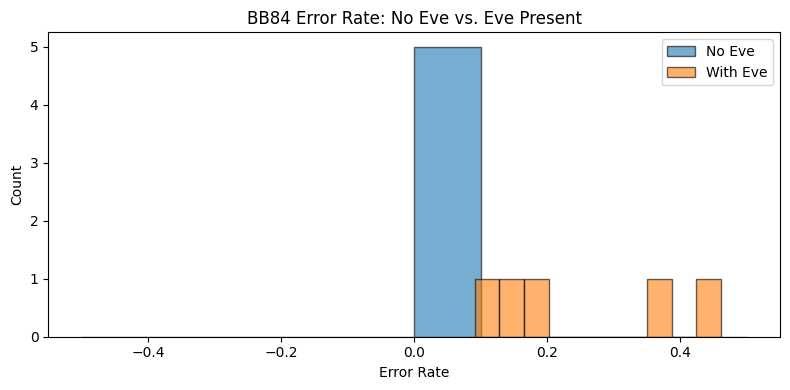

No Eve  — mean: 0.0000, std: 0.0000
With Eve — mean: 0.2522, std: 0.1427


In [9]:
def collect_error_rates(n_bits=100, n_trials=50, with_eve=False, seed=None):
    """Run many trials and collect error rates."""
    rates = []
    for t in range(n_trials):
        trial_seed = (seed + t) if seed is not None else None
        if with_eve:
            r = bb84_with_eve(n_bits=n_bits, seed=trial_seed)
            rates.append(r['error_rate'])
        else:
            r = bb84_protocol(n_bits=n_bits, seed=trial_seed)
            matched = r['matching_indices']
            if len(matched) > 0:
                errs = sum(r['alice_bits'][i] != r['bob_results'][i]
                           for i in matched)
                rates.append(errs / len(matched))
            else:
                rates.append(0.0)
    return rates

# TODO: Collect error rates for both scenarios
no_eve_rates = collect_error_rates(n_bits=25, n_trials=5,
                                   with_eve=False, seed=100)
eve_rates = collect_error_rates(n_bits=25, n_trials=5,
                                with_eve=True, seed=200)

# TODO: Plot histograms on the same axes
fig, ax = plt.subplots(figsize=(8, 4))
# Your plotting code here:
# ax.hist(no_eve_rates, ...)
# ax.hist(eve_rates, ...)
ax.hist(no_eve_rates, bins=10, alpha=0.6, label="No Eve", edgecolor="black")
ax.hist(eve_rates, bins=10, alpha=0.6, label="With Eve", edgecolor="black")
ax.set_xlabel("Error Rate")
ax.set_ylabel("Count")
ax.set_title("BB84 Error Rate: No Eve vs. Eve Present")
ax.legend()
plt.tight_layout()
plt.show()

print(f"No Eve  — mean: {np.mean(no_eve_rates):.4f}, "
      f"std: {np.std(no_eve_rates):.4f}")
print(f"With Eve — mean: {np.mean(eve_rates):.4f}, "
      f"std: {np.std(eve_rates):.4f}")


 ### Exercise 2.2 (7 points)

 **Partial Eavesdropping**



 What if Eve only intercepts a fraction of the qubits? Sweep the

 eavesdropping fraction from 0 to 1 and plot the resulting error rate.

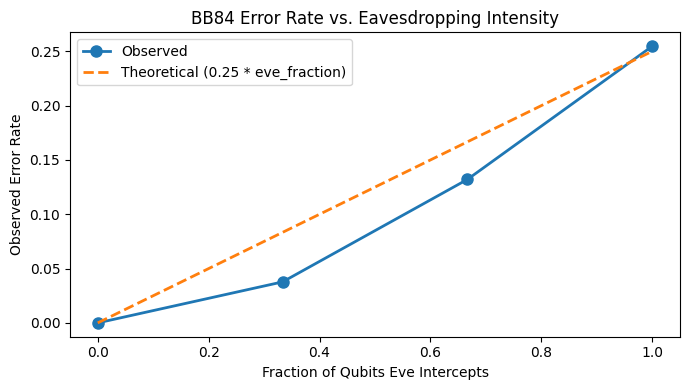

In [10]:
def bb84_partial_eve(n_bits=200, eve_fraction=0.5, seed=None):
    """BB84 where Eve intercepts each qubit with probability eve_fraction."""
    if seed is not None:
        np.random.seed(seed)

    alice_bits = [np.random.randint(0, 2) for _ in range(n_bits)]
    alice_bases = [np.random.choice(['Z', 'X']) for _ in range(n_bits)]
    bob_bases = [np.random.choice(['Z', 'X']) for _ in range(n_bits)]
    bob_results = []

    for i in range(n_bits):
        qc = bb84_encode(alice_bits[i], alice_bases[i])

        # TODO: With probability eve_fraction, Eve intercepts
        if np.random.random() < eve_fraction:
            eve_basis = np.random.choice(['Z', 'X'])
            qc_eve = qc.copy()
            qc_eve = bb84_measure(qc_eve, eve_basis)
            counts_eve = run_circuit(qc_eve, shots=1)
            eve_bit = int(list(counts_eve.keys())[0])
            qc = bb84_encode(eve_bit, eve_basis)

        qc = bb84_measure(qc, bob_bases[i])
        counts = run_circuit(qc, shots=1)
        bob_results.append(int(list(counts.keys())[0]))

    matching = [i for i in range(n_bits) if alice_bases[i] == bob_bases[i]]
    if len(matching) > 0:
        errors = sum(alice_bits[i] != bob_results[i] for i in matching)
        error_rate = errors / len(matching)
    else:
        error_rate = 0.0
    return {'error_rate': error_rate}

# TODO: Sweep eve_fraction from 0 to 1 and collect error rates
fractions = np.linspace(0, 1, 4)
observed_rates = []
for f in fractions:
    r = bb84_partial_eve(n_bits=200, eve_fraction=f, seed=42)
    observed_rates.append(r['error_rate'])

# TODO: Plot observed error rate vs. eve_fraction
#       Also plot the theoretical line: error_rate = eve_fraction * 0.25
fig, ax = plt.subplots(figsize=(7, 4))
# Your plotting code here
ax.plot(fractions, observed_rates, "o-", linewidth=2, markersize=8, label="Observed")
ax.plot(fractions, fractions * 0.25, "--", linewidth=2, label="Theoretical (0.25 * eve_fraction)")
ax.set_xlabel("Fraction of Qubits Eve Intercepts")
ax.set_ylabel("Observed Error Rate")
ax.set_title("BB84 Error Rate vs. Eavesdropping Intensity")
ax.legend()
plt.tight_layout()
plt.show()


 ---

 ## Part 3: Oracle Construction (20 points)



 An **oracle** encodes a classical function into a quantum operation.

 We work with two types:

 - **Phase oracle:** $U_f|x\rangle = (-1)^{f(x)}|x\rangle$

 - **Standard oracle:** $U_f|x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$

 ### Exercise 3.1 (7 points)

 **Phase Oracles**



 Build phase oracles for 1-bit functions. Recall there are four:



 | Name | $f(0)$ | $f(1)$ | Type |

 |------|--------|--------|------|

 | $f_0$ | 0 | 0 | Constant |

 | $f_1$ | 0 | 1 | Balanced |

 | $f_2$ | 1 | 0 | Balanced |

 | $f_3$ | 1 | 1 | Constant |

In [11]:
def phase_oracle_1bit(f_name):
    """
    Create a 1-qubit phase oracle for the given function.

    Args:
        f_name: str — 'f0', 'f1', 'f2', or 'f3'

    Returns:
        QuantumCircuit implementing U_f|x⟩ = (-1)^{f(x)}|x⟩
    """
    qc = QuantumCircuit(1)

    # TODO: Implement each oracle
    # f0: f(0)=0, f(1)=0 → identity
    # f1: f(0)=0, f(1)=1 → flip phase of |1⟩ only → which gate?
    # f2: f(0)=1, f(1)=0 → flip phase of |0⟩ only → think X, Z, X
    # f3: f(0)=1, f(1)=1 → flip phase of both → global phase
    # Your code here
    if f_name == 'f0':
        pass              # identity (no gates)
    elif f_name == 'f1':
        qc.z(0)           # Z gate (flip |1⟩)
    elif f_name == 'f2':
        qc.x(0)           # X-Z-X (flip |0⟩)
        qc.z(0)
        qc.x(0)
    elif f_name == 'f3':
        qc.z(0)           # Z gate (global phase)

    return qc

# Test: verify each oracle's action
print("Phase Oracle Verification:")
for name in ['f0', 'f1', 'f2', 'f3']:
    qc = phase_oracle_1bit(name)
    op = Operator(qc)
    sv0 = Statevector.from_label('0').evolve(op)
    sv1 = Statevector.from_label('1').evolve(op)
    phase0 = sv0[0].real
    phase1 = sv1[1].real
    print(f"  {name}: |0⟩ → {phase0:+.0f}|0⟩,  |1⟩ → {phase1:+.0f}|1⟩")


Phase Oracle Verification:
  f0: |0⟩ → +1|0⟩,  |1⟩ → +1|1⟩
  f1: |0⟩ → +1|0⟩,  |1⟩ → -1|1⟩
  f2: |0⟩ → -1|0⟩,  |1⟩ → +1|1⟩
  f3: |0⟩ → +1|0⟩,  |1⟩ → -1|1⟩


 ### Exercise 3.2 (6 points)

 **Multi-Qubit Phase Oracles**



 Build phase oracles for 3-qubit functions using Z gates.

 Recall: $(-1)^{x_i \oplus x_j} = (-1)^{x_i} \cdot (-1)^{x_j}$,

 so XOR parity oracles are just Z on each selected qubit.

In [12]:
def phase_oracle_nbit(n, function_type, **kwargs):
    """
    Create an n-qubit phase oracle.

    Args:
        n: number of qubits
        function_type: str —
            'constant_0': f(x) = 0 for all x
            'constant_1': f(x) = 1 for all x
            'single_bit': f(x) = x_i, requires kwarg 'target'
            'parity': f(x) = XOR of selected bits, requires kwarg 'bits'

    Returns:
        QuantumCircuit (n qubits, phase oracle)
    """
    qc = QuantumCircuit(n)

    if function_type == 'constant_0':
        pass  # TODO: identity — no gates needed

    elif function_type == 'constant_1':
        # TODO: global phase -1
        # Hint: X-Z-X-Z on any qubit gives a -1 global phase
        qc.x(0)
        qc.z(0)
        qc.x(0)
        qc.z(0)

    elif function_type == 'single_bit':
        target = kwargs['target']
        # TODO: f(x) = x_target → which single gate?
        qc.z(target)

    elif function_type == 'parity':
        bits = kwargs['bits']
        # TODO: f(x) = XOR of selected bits → Z on each
        for bit_index in bits:
            qc.z(bit_index)  # Z on each selected qubit

    return qc

# Test all oracle types with n=3
print("Multi-Qubit Phase Oracle Tests (n=3):")
test_cases = [
    ('constant_0', {}),
    ('constant_1', {}),
    ('single_bit', {'target': 0}),
    ('single_bit', {'target': 2}),
    ('parity', {'bits': [0, 1]}),
    ('parity', {'bits': [0, 1, 2]}),
]

for ftype, kw in test_cases:
    oracle = phase_oracle_nbit(3, ftype, **kw)
    # Apply to |+++⟩ and check phases
    qc_test = QuantumCircuit(3)
    for i in range(3):
        qc_test.h(i)
    qc_test.compose(oracle, inplace=True)
    for i in range(3):
        qc_test.h(i)
    qc_test.measure_all()
    counts = run_circuit(qc_test, shots=10)
    result = max(counts, key=counts.get)
    kw_str = str(kw) if kw else ''
    print(f"  {ftype:12s} {kw_str:20s} → {result}")


Multi-Qubit Phase Oracle Tests (n=3):
  constant_0                        → 000
  constant_1                        → 000
  single_bit   {'target': 0}        → 001
  single_bit   {'target': 2}        → 100
  parity       {'bits': [0, 1]}     → 011
  parity       {'bits': [0, 1, 2]}  → 111


 ### Exercise 3.3 (7 points)

 **General Oracle with Ancilla**



 Build a standard oracle for an arbitrary function specified by the

 set of inputs where $f(x) = 1$. Use multi-controlled X gates.

In [13]:
def general_oracle(n, ones_set):
    """
    Standard oracle: f(x)=1 for x in ones_set.
    Qubit n is the ancilla (target).

    Args:
        n: number of input qubits
        ones_set: list of n-bit strings where f(x) = 1

    Returns:
        QuantumCircuit on n+1 qubits
    """
    qc = QuantumCircuit(n + 1)

    for pattern in ones_set:
        # TODO: For each pattern where f(x) = 1:
        # 1. Apply X to input qubits that should be |0⟩ in the pattern
        #    (to turn the condition into "all qubits are |1⟩")
        # 2. Apply multi-controlled X (mcx) on ancilla
        # 3. Undo the X gates from step 1
        # Your code here
        for i, bit in enumerate(pattern):
            if bit == '0':
                qc.x(i)
    
    # Step 2: Multi-controlled X on ancilla
        qc.mcx(list(range(n)), n)
    
    # Step 3: Undo the X gates
        for i, bit in enumerate(pattern):
            if bit == '0':
                qc.x(i)

    return qc

# Also define the DJ function for standard oracles
def deutsch_jozsa_standard(oracle, n):
    """DJ using a standard oracle (ancilla in |−⟩)."""
    qc = QuantumCircuit(n + 1, n)
    qc.x(n); qc.h(n)
    for i in range(n):
        qc.h(i)
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    for i in range(n):
        qc.h(i)
    qc.measure(range(n), range(n))
    return qc

# Test: a balanced function f=1 for {010, 011, 100, 101}
oracle = general_oracle(3, ['010', '011', '100', '101'])
qc = deutsch_jozsa_standard(oracle, 3)
counts = run_circuit(qc, shots=10)
result = max(counts, key=counts.get)
print(f"General oracle test: {counts}")
print(f"Is '000'? {result == '000'} → {'constant' if result == '000' else 'balanced'}")


General oracle test: {'011': 10}
Is '000'? False → balanced


 ---

 ## Part 4: Deutsch-Jozsa Algorithm (25 points)

 ### Exercise 4.1 (8 points)

 **Implement DJ with Phase Oracles**



 Complete the DJ function for phase oracles and test it on all oracle

 types from Exercise 3.2.

In [14]:
def deutsch_jozsa_phase(oracle, n):
    """
    Run Deutsch-Jozsa using a phase oracle (no ancilla).

    Args:
        oracle: QuantumCircuit on n qubits (phase oracle)
        n: number of input qubits

    Returns:
        QuantumCircuit with measurement
    """
    qc = QuantumCircuit(n, n)

    # TODO: Step 1 — Apply H to all input qubits
    # Your code here

    for qubit in range(n):
        qc.h(qubit)

    # TODO: Step 2 — Apply the phase oracle
    # Your code here

    qc.compose(oracle, inplace=True)

    # TODO: Step 3 — Apply H again to all input qubits
    # Your code here
    for qubit in range(n):
        qc.h(qubit)

    # TODO: Step 4 — Measure all qubits
    # Your code here
    for i in range(n):
        qc.measure(i, i)

    return qc

# Test DJ on all oracle types
print("Deutsch-Jozsa Results (n=3):")
print("-" * 50)
test_oracles = [
    ('constant_0', {}, 'constant'),
    ('constant_1', {}, 'constant'),
    ('single_bit', {'target': 0}, 'balanced'),
    ('single_bit', {'target': 2}, 'balanced'),
    ('parity', {'bits': [0, 1]}, 'balanced'),
    ('parity', {'bits': [0, 1, 2]}, 'balanced'),
]

for ftype, kw, expected in test_oracles:
    oracle = phase_oracle_nbit(3, ftype, **kw)
    qc = deutsch_jozsa_phase(oracle, 3)
    counts = run_circuit(qc, shots=100)
    result = max(counts, key=counts.get)
    classification = "constant" if result == '000' else "balanced"
    status = "✓" if classification == expected else "✗"
    kw_str = str(kw) if kw else ''
    print(f"  {ftype:12s} {kw_str:20s} → {result:5s} "
          f"({classification}) {status}")


Deutsch-Jozsa Results (n=3):
--------------------------------------------------
  constant_0                        → 000   (constant) ✓
  constant_1                        → 000   (constant) ✓
  single_bit   {'target': 0}        → 001   (balanced) ✓
  single_bit   {'target': 2}        → 100   (balanced) ✓
  parity       {'bits': [0, 1]}     → 011   (balanced) ✓
  parity       {'bits': [0, 1, 2]}  → 111   (balanced) ✓


 ### Exercise 4.2 (10 points)

 **DJ with Standard Oracles**



 Test DJ on the general oracle from Exercise 3.3. Create three

 different balanced functions and one constant function, run DJ on

 each, and verify the results.

In [15]:
# TODO: Create 4 oracles (3 balanced, 1 constant) using general_oracle
# Balanced functions must have f=1 for exactly half the inputs (4 out of 8)

# Oracle A: constant — f(x) = 0 for all x
oracle_a = general_oracle(3, [])  # empty ones_set → always 0

# Oracle B: balanced — f=1 for {000, 001, 010, 011}
oracle_b = general_oracle(3, ['000', '001', '010', '011'])  # TODO

# Oracle C: balanced — f=1 for {001, 010, 100, 111}
oracle_c = general_oracle(3, ['001', '010', '100', '111'])  # TODO

# Oracle D: balanced — choose your own set of 4 inputs
oracle_d = general_oracle(3, ['011', '100', '101', '110'])

# Run DJ on each
print("DJ with Standard Oracles (n=3):")
print("-" * 40)
oracles = {'A (constant)': oracle_a,
           'B (balanced)': oracle_b,
           'C (balanced)': oracle_c,
           'D (balanced)': oracle_d}

for name, oracle in oracles.items():
    if oracle is not None:
        qc = deutsch_jozsa_standard(oracle, 3)
        counts = run_circuit(qc, shots=100)
        result = max(counts, key=counts.get)
        classification = "constant" if result == '000' else "balanced"
        print(f"  {name}: {counts} → {classification}")


DJ with Standard Oracles (n=3):
----------------------------------------
  A (constant): {'000': 100} → constant
  B (balanced): {'001': 100} → balanced
  C (balanced): {'111': 100} → balanced
  D (balanced): {'111': 30, '101': 34, '001': 19, '011': 17} → balanced


 ### Exercise 4.3 (7 points)

 **Interpreting DJ Output**



 For phase oracles built from Z gates, the DJ output string is

 deterministic. Predict the output before running, then verify.

In [16]:
# For each oracle below:
# 1. Predict what DJ will output (write your prediction in the comment)
# 2. Run and verify

# Oracle 1: Z on qubit 0 only
# Prediction: 0001 (qubit 0 flipped)
oracle1 = QuantumCircuit(4)
oracle1.z(0)
qc1 = deutsch_jozsa_phase(oracle1, 4)
counts1 = run_circuit(qc1, shots=100)
print(f"Z on q0:          {counts1}")

# Oracle 2: Z on qubit 2 only
# Prediction: 0100 (qubit 2 flipped)
oracle2 = QuantumCircuit(4)
oracle2.z(2)
qc2 = deutsch_jozsa_phase(oracle2, 4)
counts2 = run_circuit(qc2, shots=100)
print(f"Z on q2:          {counts2}")

# Oracle 3: Z on qubits 0 and 3
# Prediction: 1001 (qubits 0, 3 flipped)
oracle3 = QuantumCircuit(4)
oracle3.z(0)
oracle3.z(3)
qc3 = deutsch_jozsa_phase(oracle3, 4)
counts3 = run_circuit(qc3, shots=100)
print(f"Z on q0, q3:      {counts3}")

# Oracle 4: Z on qubits 0, 1, and 2
# Prediction: 0111 (qubits 0, 1, 2 flipped)
oracle4 = QuantumCircuit(4)
oracle4.z(0)
oracle4.z(1)
oracle4.z(2)
qc4 = deutsch_jozsa_phase(oracle4, 4)
counts4 = run_circuit(qc4, shots=100)
print(f"Z on q0, q1, q2:  {counts4}")

# TODO: Explain in 1-2 sentences: what is the relationship between
#       which qubits have Z gates and the measurement result?
# Your answer (as a comment):
# Z gates on specific qubits cause those qubits to measure as |1⟩ in the output.


Z on q0:          {'0001': 100}
Z on q2:          {'0100': 100}
Z on q0, q3:      {'1001': 100}
Z on q0, q1, q2:  {'0111': 100}


 ---

 ## Part 5: Bernstein-Vazirani (15 points)

 ### Exercise 5.1 (8 points)

 **Implement BV and Recover Secret Strings**



 Build BV oracles and use the DJ circuit to recover hidden strings.

In [17]:
def bv_oracle(n, secret):
    """
    Phase oracle for f(x) = s · x (bitwise inner product mod 2).

    Args:
        n: number of qubits
        secret: n-bit string, e.g. '101'

    Returns:
        QuantumCircuit (n qubits, phase oracle)
    """
    qc = QuantumCircuit(n)

    # TODO: Apply Z to qubit i wherever secret bit i is '1'
    # Remember Qiskit is little-endian: qubit 0 = rightmost bit
    # Your code here
    for i, bit in enumerate(secret):
        if bit == '1':
            qc.z(n - 1 - i)

    return qc

# Test: recover all 3-bit secrets
print("Bernstein-Vazirani (n=3):")
print("-" * 40)
all_correct = True
for s in ['001', '010', '011', '100', '101', '110', '111']:
    oracle = bv_oracle(3, s)
    qc = deutsch_jozsa_phase(oracle, 3)
    counts = run_circuit(qc, shots=1)
    measured = list(counts.keys())[0]
    match = "✓" if measured == s else "✗"
    if measured != s:
        all_correct = False
    print(f"  Secret: {s} → Measured: {measured} {match}")

print(f"\nAll correct: {all_correct}")


Bernstein-Vazirani (n=3):
----------------------------------------
  Secret: 001 → Measured: 001 ✓
  Secret: 010 → Measured: 010 ✓
  Secret: 011 → Measured: 011 ✓
  Secret: 100 → Measured: 100 ✓
  Secret: 101 → Measured: 101 ✓
  Secret: 110 → Measured: 110 ✓
  Secret: 111 → Measured: 111 ✓

All correct: True


 ### Exercise 5.2 (7 points)

 **Scaling BV**



 Test BV for increasing $n$ and compare with classical query count.

BV Scaling:
   n          Secret        Measured  Match   Classical Queries
-----------------------------------------------------------------
   2              10              10      ✓                   2
   4            1010            1010      ✓                   4
   6          101010          101010      ✓                   6
   8        10101010        10101010      ✓                   8
  10      1010101010      1010101010      ✓                  10
  12    101010101010    101010101010      ✓                  12


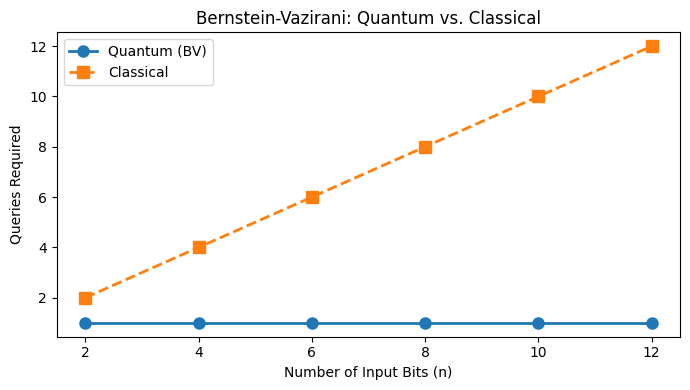

In [18]:
# TODO: Run BV for n = 2, 4, 6, 8, 10, 12
#       For each n, use secret = '10' * (n//2) (alternating 1s and 0s)
#       Record: n, secret recovered correctly?, classical queries needed

print("BV Scaling:")
print(f"{'n':>4s}  {'Secret':>14s}  {'Measured':>14s}  {'Match':>5s}  "
      f"{'Classical Queries':>18s}")
print("-" * 65)

for n in [2, 4, 6, 8, 10, 12]:
    secret = ('10' * (n // 2))[:n]

    # TODO: Build BV oracle and run DJ circuit
    oracle = bv_oracle(n, secret)   # Your code here
    qc = deutsch_jozsa_phase(oracle, n)     # Your code here
    counts = run_circuit(qc, shots=1)   # Your code here
    measured = list(counts.keys())[0]  # Your code here

    classical_queries = n  # BV classical cost
    match = "✓" if measured == secret else "✗"
    print(f"{n:4d}  {secret:>14s}  {measured:>14s}  {match:>5s}  "
          f"{classical_queries:>18d}")

# TODO: Plot quantum queries (always 1) vs classical queries (n)
fig, ax = plt.subplots(figsize=(7, 4))
ns = [2, 4, 6, 8, 10, 12]
# Your plotting code here:
# ax.plot(ns, [1]*len(ns), ...)      # quantum
# ax.plot(ns, ns, ...)                # classical
ax.plot(ns, [1]*len(ns), "o-", linewidth=2, markersize=8, label="Quantum (BV)")
ax.plot(ns, ns, "s--", linewidth=2, markersize=8, label="Classical")
ax.set_xlabel("Number of Input Bits (n)")
ax.set_ylabel("Queries Required")
ax.set_title("Bernstein-Vazirani: Quantum vs. Classical")
ax.legend()
plt.tight_layout()
plt.show()


 ---

 ## Bonus: Mystery Oracle Challenge (15 points)



 You are given 5 black-box oracles. For each one, determine:

 1. Is it constant or balanced?

 2. If balanced, what is the hidden structure?

 3. Justify your answer.

In [19]:
# Mystery oracles — DO NOT read the implementations!
# (In a real setting these would be imported from a hidden module.)

def _make_mysteries():
    """Generate 5 mystery oracles. Call once, then classify each."""
    # Mystery 1: phase oracle, n=4
    m1 = QuantumCircuit(4)
    m1.z(1)
    m1.z(3)

    # Mystery 2: standard oracle, n=4
    m2 = QuantumCircuit(5)
    m2.x(4)

    # Mystery 3: phase oracle, n=4
    m3 = QuantumCircuit(4)

    # Mystery 4: standard oracle, n=4
    m4 = QuantumCircuit(5)
    m4.cx(0, 4)
    m4.cx(2, 4)

    # Mystery 5: phase oracle, n=4
    m5 = QuantumCircuit(4)
    m5.z(0)
    m5.z(1)
    m5.z(2)
    m5.z(3)

    return {
        'mystery_1': ('phase', m1),
        'mystery_2': ('standard', m2),
        'mystery_3': ('phase', m3),
        'mystery_4': ('standard', m4),
        'mystery_5': ('phase', m5),
    }

mysteries = _make_mysteries()

# TODO: For each mystery oracle, run the appropriate DJ function
#       and classify as constant or balanced.
#       If balanced, determine the hidden string/structure.

print("Mystery Oracle Classification:")
print("=" * 60)

for name, (oracle_type, oracle) in mysteries.items():
    # TODO: Choose the right DJ function based on oracle_type
    if oracle_type == 'phase':
        qc = deutsch_jozsa_phase(oracle, 4)  # Your code here
    else:
        qc = deutsch_jozsa_standard(oracle, 4)  # Your code here

    # counts = run_circuit(qc, shots=100)
    # result = max(counts, key=counts.get)
    # classification = ...
    counts = run_circuit(qc, shots=100)
    result = max(counts, key=counts.get)
    classification = "CONSTANT" if result == '0000' else "BALANCED"
    
    # TODO: Print your classification and reasoning
    print(f"\n{name} ({oracle_type} oracle):")
    # print(f"  Measurement: {counts}")
    # print(f"  Classification: ...")
    # print(f"  Hidden structure: ...")

    print(f"\n{name} ({oracle_type} oracle):")
    print(f"  Result: {result}")
    print(f"  Classification: {classification}")

Mystery Oracle Classification:

mystery_1 (phase oracle):

mystery_1 (phase oracle):
  Result: 1010
  Classification: BALANCED

mystery_2 (standard oracle):

mystery_2 (standard oracle):
  Result: 0000
  Classification: CONSTANT

mystery_3 (phase oracle):

mystery_3 (phase oracle):
  Result: 0000
  Classification: CONSTANT

mystery_4 (standard oracle):

mystery_4 (standard oracle):
  Result: 0101
  Classification: BALANCED

mystery_5 (phase oracle):

mystery_5 (phase oracle):
  Result: 1111
  Classification: BALANCED


 ---

 ## Submission Checklist



 Before submitting, verify:

 - [ ] All code cells run without errors

 - [ ] All TODO sections are completed

 - [ ] Prediction comments filled in (Exercise 4.3)

 - [ ] Plots are visible and labeled

 - [ ] Bonus section attempted (optional)



 **Submit via Canvas by Tuesday 11:59 PM**